# Data Preparation Using the Quadrant Model

This notebook uses the trained quadrant model to prepare the Stage 2 and Stage 3 data. We check how well the quadrant model crops each split, drop the files it failed on, then export quadrant crops paired with the enumeration and disease labels. By the end we'll have cropped, split data ready for Stage 2 training, plus an augmented version of the enumeration set.

The functions doing most of the work here, `compare_best_vs_last`, `export_enum_by_quad_using_model`, and `analyze_quadrant_predictions`, come from `src/model_utils.py`. `apply_smart_aug` comes from `src/utils.py`.

In [ ]:
import pandas as pd
import os
import sys
import warnings
warnings.filterwarnings('ignore')
# add the project root to the path so the src package can be imported
sys.path.append(os.path.abspath('..'))

import yaml
from ultralytics import YOLO
from src.utils import apply_smart_aug
from src.model_utils import export_enum_by_quad_using_model,analyze_quadrant_predictions,compare_best_vs_last


In [ ]:
with open('../configs/stage1.yaml','r') as f:

    stage1_config = yaml.safe_load(f)


with open('../configs/stage2.yaml','r') as f:

    stage2_config = yaml.safe_load(f)


with open('../configs/stage2_continued.yaml','r') as f:

    stage2_cont_config = yaml.safe_load(f)


with open('../configs/stage3.yaml','r') as f:

    stage3_config = yaml.safe_load(f)


with open(stage2_config['model_args']['data'],'r') as f:

    enum_data_yaml = yaml.safe_load(f)


with open('../configs/trained_models.yaml','r') as f:

    trained_models_config = yaml.safe_load(f)

In [ ]:
# Here we will use train set cause the enum dataset is diff with quad dataset
s2_train_results = compare_best_vs_last(trained_models_config,
                                'quad',
                                stage2_config['paths']['original_images_path'],
                                os.path.join(stage2_config['paths']['s2_main_path'], 'train_df (splitted).pkl'),
                                export_result_path=os.path.join('../Runs/Stage 2/Quadrant Model Crop Analysis','train'))


Running best and last weights on the test set
quadrant_detection_model - best


100%|██████████| 502/502 [01:12<00:00,  6.97it/s]


  duplicates: 16, low_confidence: 15, missing: 4, successful: 2002, avg_conf: 0.9785
quadrant_detection_model - last


100%|██████████| 502/502 [01:10<00:00,  7.17it/s]

  duplicates: 15, low_confidence: 13, missing: 4, successful: 2003, avg_conf: 0.9807

Test set summary
quadrant_detection_model_best: total_errors=35, avg_confidence=0.9785
quadrant_detection_model_last: total_errors=32, avg_confidence=0.9807

Lowest total errors on test set: quadrant_detection_model_last with 32 errors


In [ ]:
s2_valid_results = compare_best_vs_last(trained_models_config,
                                'quad',
                                stage2_config['paths']['original_images_path'],
                                os.path.join(stage2_config['paths']['s2_main_path'], 'valid_df (splitted).pkl'),
                                export_result_path=os.path.join('../Runs/Stage 2/Quadrant Model Crop Analysis','valid'))


Running best and last weights on the test set
quadrant_detection_model - best


100%|██████████| 64/64 [00:08<00:00,  7.39it/s]


  duplicates: 3, low_confidence: 5, missing: 1, successful: 255, avg_conf: 0.9691
quadrant_detection_model - last


100%|██████████| 64/64 [00:08<00:00,  7.51it/s]

  duplicates: 1, low_confidence: 5, missing: 1, successful: 255, avg_conf: 0.9745

Test set summary
quadrant_detection_model_best: total_errors=9, avg_confidence=0.9691
quadrant_detection_model_last: total_errors=7, avg_confidence=0.9745

Lowest total errors on test set: quadrant_detection_model_last with 7 errors


In [ ]:
s2_test_results = compare_best_vs_last(trained_models_config,
                                'quad',
                                stage2_config['paths']['original_images_path'],
                                os.path.join(stage2_config['paths']['s2_main_path'], 'test_df (splitted).pkl'),
                                export_result_path=os.path.join('../Runs/Stage 2/Quadrant Model Crop Analysis','test'))


Running best and last weights on the test set
quadrant_detection_model - best


100%|██████████| 64/64 [00:08<00:00,  7.50it/s]


  duplicates: 2, low_confidence: 4, missing: 0, successful: 256, avg_conf: 0.9763
quadrant_detection_model - last


100%|██████████| 64/64 [00:08<00:00,  7.81it/s]

  duplicates: 1, low_confidence: 2, missing: 0, successful: 256, avg_conf: 0.9829

Test set summary
quadrant_detection_model_best: total_errors=6, avg_confidence=0.9763
quadrant_detection_model_last: total_errors=3, avg_confidence=0.9829

Lowest total errors on test set: quadrant_detection_model_last with 3 errors


In [ ]:
# Also Here we will use train set cause the diseases dataset is diff with quad dataset
s3_train_results = compare_best_vs_last(trained_models_config,
                                'quad',
                                stage3_config['paths']['original_images_path'],
                                os.path.join(stage3_config['paths']['s3_main_path'], 'train_df (splitted).pkl'),
                                export_result_path=os.path.join('../Runs/Stage 3/Quadrant Model Crop Analysis','train'))


Running best and last weights on the test set
quadrant_detection_model - best


100%|██████████| 538/538 [01:19<00:00,  6.77it/s]


  duplicates: 21, low_confidence: 15, missing: 7, successful: 2143, avg_conf: 0.9766
quadrant_detection_model - last


100%|██████████| 538/538 [01:20<00:00,  6.71it/s]

  duplicates: 15, low_confidence: 17, missing: 6, successful: 2144, avg_conf: 0.9795

Test set summary
quadrant_detection_model_best: total_errors=43, avg_confidence=0.9766
quadrant_detection_model_last: total_errors=38, avg_confidence=0.9795

Lowest total errors on test set: quadrant_detection_model_last with 38 errors


In [ ]:
s3_valid_results = compare_best_vs_last(trained_models_config,
                                        'quad',
                                        stage3_config['paths']['original_images_path'],
                                        os.path.join(stage3_config['paths']['s3_main_path'], 'valid_df (splitted).pkl'),
                                        export_result_path=os.path.join('../Runs/Stage 3/Quadrant Model Crop Analysis','valid'))


Running best and last weights on the test set
quadrant_detection_model - best


100%|██████████| 67/67 [00:10<00:00,  6.44it/s]


  duplicates: 1, low_confidence: 2, missing: 1, successful: 267, avg_conf: 0.9758
quadrant_detection_model - last


100%|██████████| 67/67 [00:08<00:00,  7.46it/s]

  duplicates: 2, low_confidence: 2, missing: 1, successful: 267, avg_conf: 0.9763

Test set summary
quadrant_detection_model_best: total_errors=4, avg_confidence=0.9758
quadrant_detection_model_last: total_errors=5, avg_confidence=0.9763

Lowest total errors on test set: quadrant_detection_model_best with 4 errors


In [ ]:
s3_test_results = compare_best_vs_last(trained_models_config,
                                        'quad',
                                        stage3_config['paths']['original_images_path'],
                                        os.path.join(stage3_config['paths']['s3_main_path'], 'test_df (splitted).pkl'),
                                        export_result_path=os.path.join('../Runs/Stage 3/Quadrant Model Crop Analysis','test'))


Running best and last weights on the test set
quadrant_detection_model - best


100%|██████████| 69/69 [00:10<00:00,  6.32it/s]


  duplicates: 2, low_confidence: 2, missing: 2, successful: 274, avg_conf: 0.9777
quadrant_detection_model - last


100%|██████████| 69/69 [00:10<00:00,  6.67it/s]

  duplicates: 0, low_confidence: 1, missing: 2, successful: 274, avg_conf: 0.9796

Test set summary
quadrant_detection_model_best: total_errors=6, avg_confidence=0.9777
quadrant_detection_model_last: total_errors=3, avg_confidence=0.9796

Lowest total errors on test set: quadrant_detection_model_last with 3 errors


Total images processed: 502
Total events logged: 2537



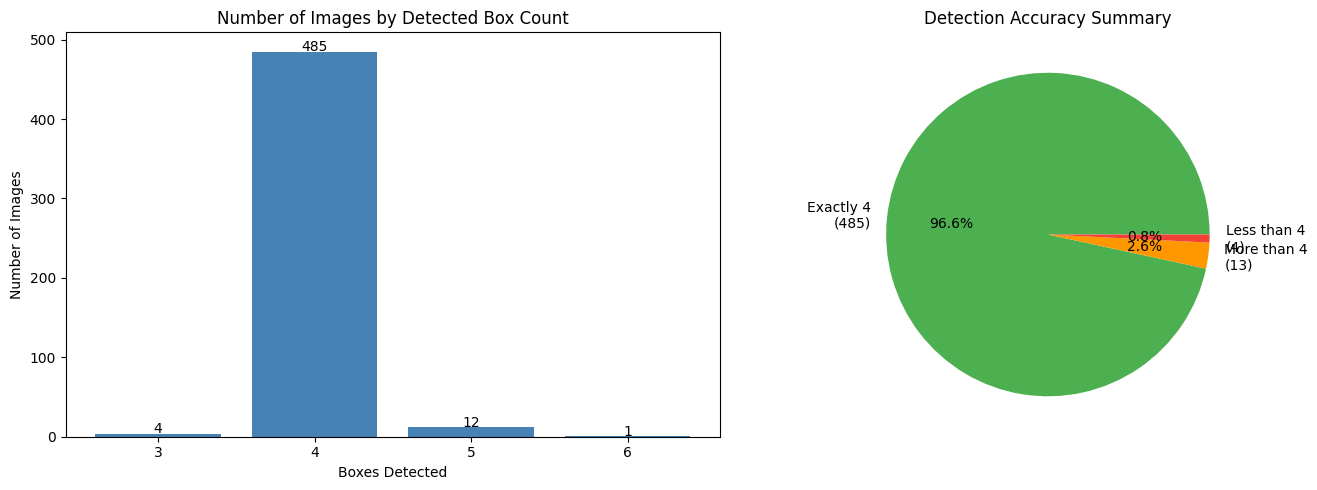

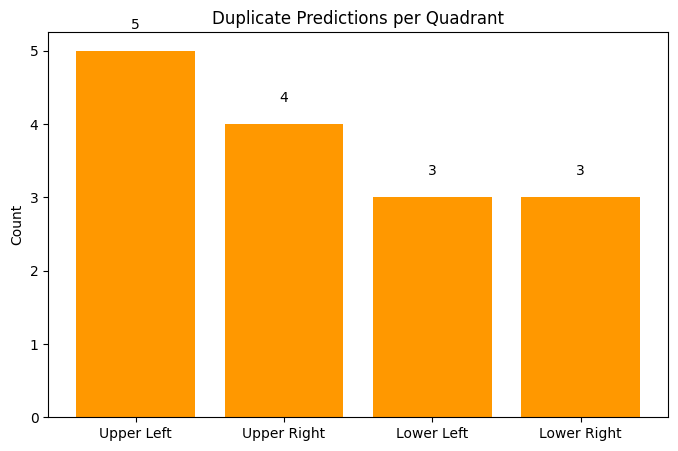

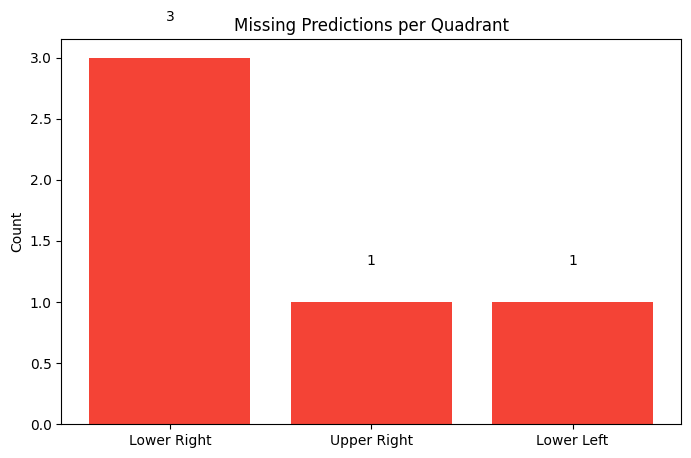

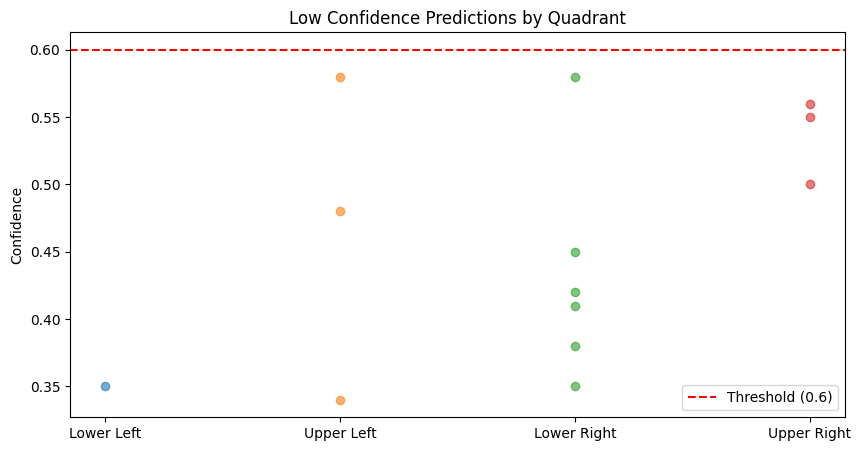


Total low confidence warnings: 13
             count      mean   min
quad                              
Lower Left       1  0.350000  0.35
Lower Right      6  0.431667  0.35
Upper Left       3  0.466667  0.34
Upper Right      3  0.536667  0.50

Average HIGH confidence (>= 0.6): 0.984
Average LOW confidence  (< 0.6): 0.444
Confidence Gap: 0.540  (std=0.083, n_low=41 -> large, model is inconsistent)


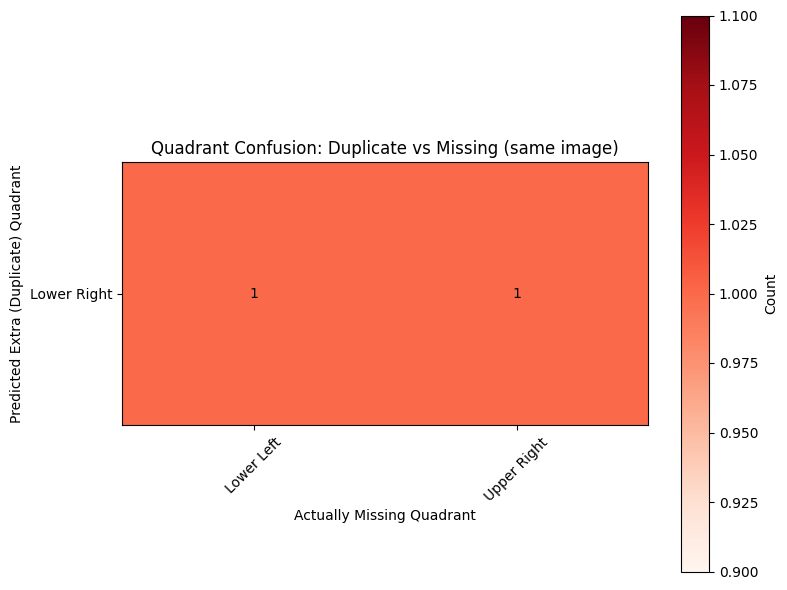


Top 10 problematic images (most warnings):
File_Name
train_273.png    4
train_502.png    2
train_214.png    2
train_174.png    2
train_176.png    1
train_266.png    1
train_255.png    1
train_44.png     1
train_170.png    1
train_615.png    1
Name: count, dtype: int64

Exported worst images log to: ../Runs/Stage 2/Quadrant Model Crop Analysis\train


In [ ]:
# pull the per-image detection log out of the results, then summarize
# duplicate / missing / low-confidence quadrants for this split
s2_train_log_df = s2_train_results['test_set_results']['quadrant_detection_model_last']['log_df']
s2_train_log_summary = analyze_quadrant_predictions(s2_train_log_df, low_conf_threshold=0.6, export_dir='../Runs/Stage 2/Quadrant Model Crop Analysis', split_name='train')

Total images processed: 502
Total events logged: 2537



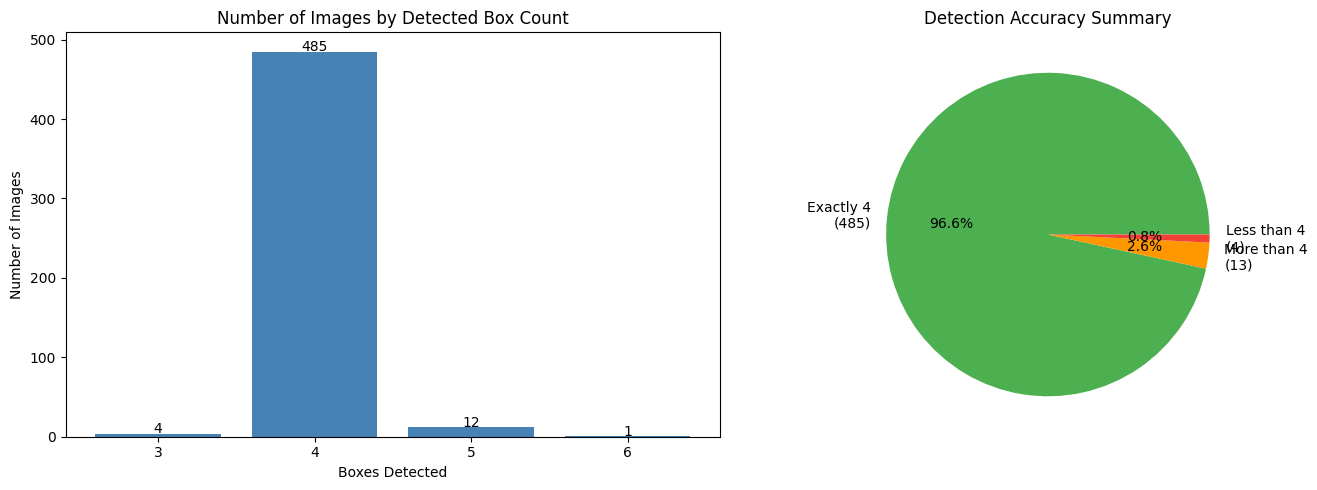

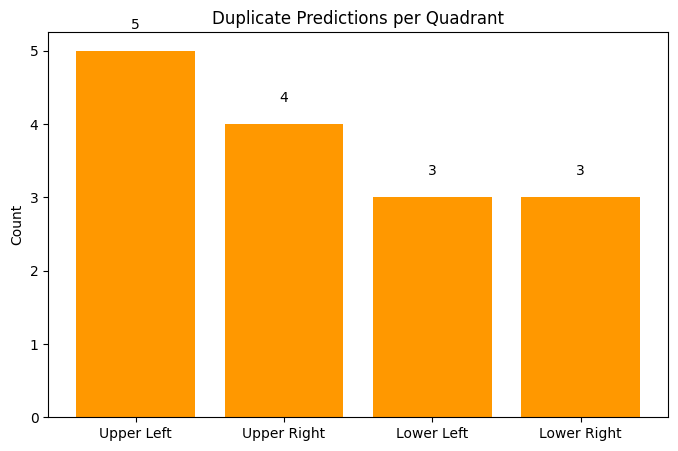

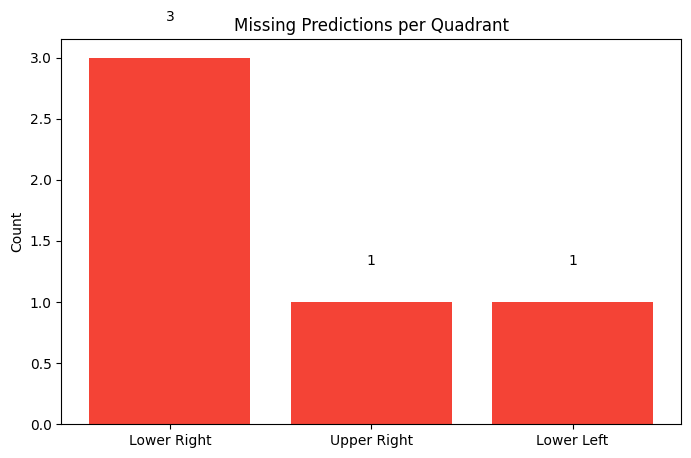

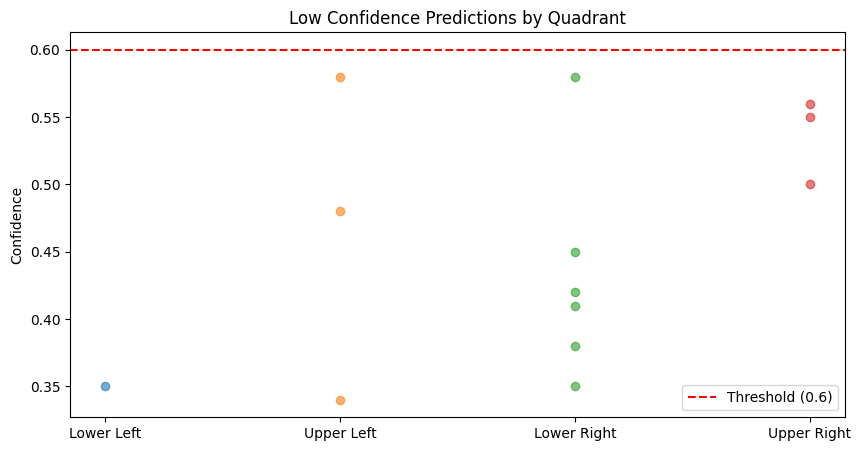


Total low confidence warnings: 13
             count      mean   min
quad                              
Lower Left       1  0.350000  0.35
Lower Right      6  0.431667  0.35
Upper Left       3  0.466667  0.34
Upper Right      3  0.536667  0.50

Average HIGH confidence (>= 0.6): 0.984
Average LOW confidence  (< 0.6): 0.444
Confidence Gap: 0.540  (std=0.083, n_low=41 -> large, model is inconsistent)


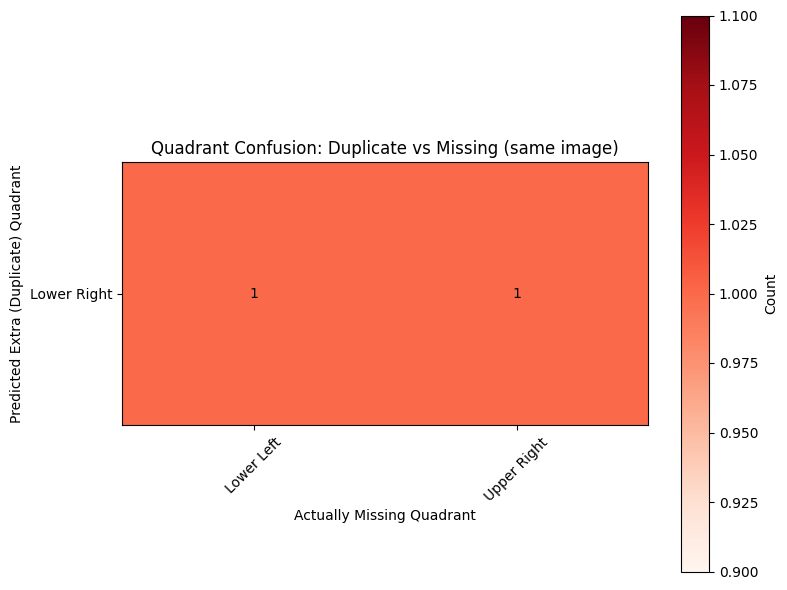


Top 10 problematic images (most warnings):
File_Name
train_273.png    4
train_502.png    2
train_214.png    2
train_174.png    2
train_176.png    1
train_266.png    1
train_255.png    1
train_44.png     1
train_170.png    1
train_615.png    1
Name: count, dtype: int64

Exported worst images log to: ../Runs/Stage 2/Quadrant Model Crop Analysis\valid


In [ ]:
s2_valid_log_df = s2_valid_results['test_set_results']['quadrant_detection_model_last']['log_df']
s2_valid_log_summary = analyze_quadrant_predictions(s2_valid_log_df, low_conf_threshold=0.6, export_dir='../Runs/Stage 2/Quadrant Model Crop Analysis', split_name='valid')

Total images processed: 502
Total events logged: 2537



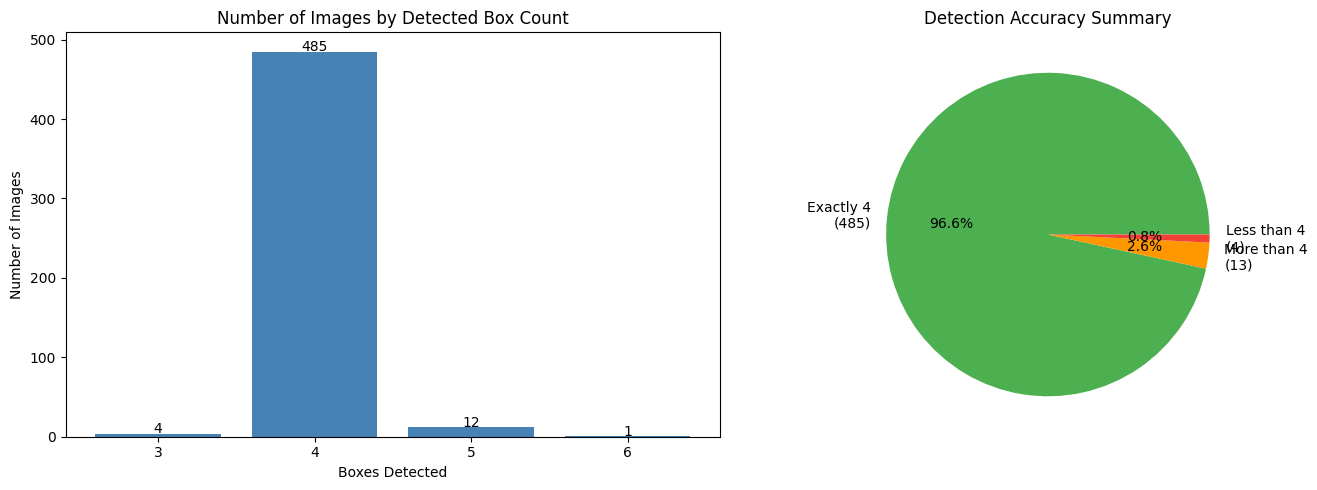

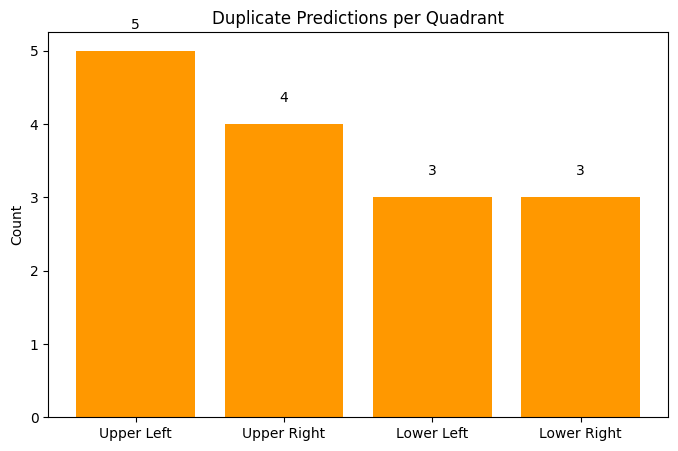

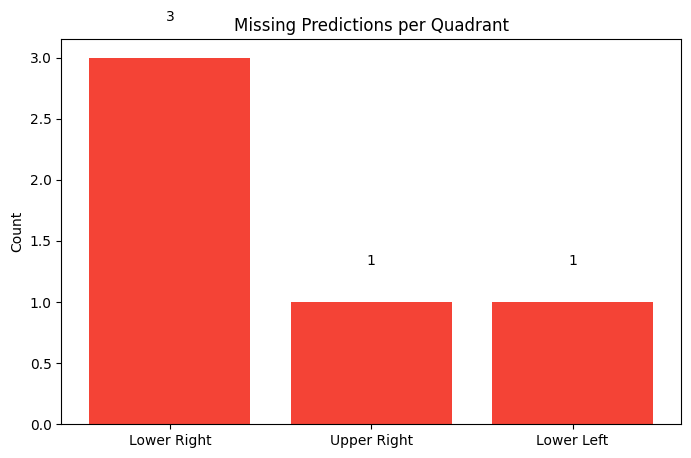

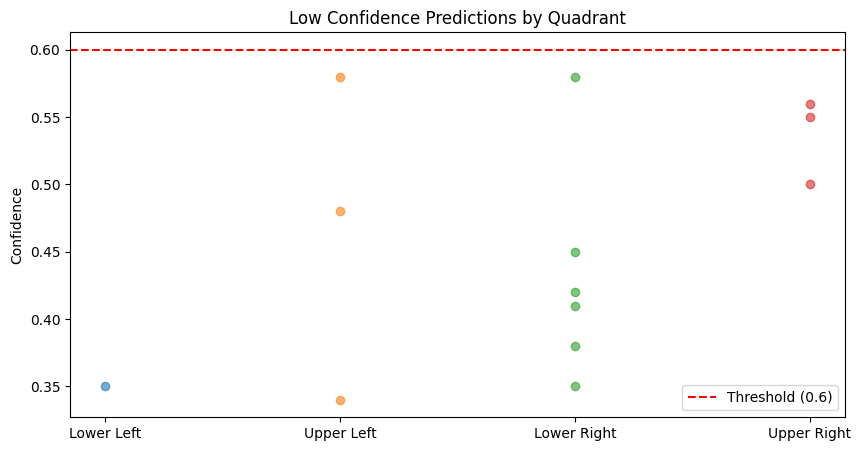


Total low confidence warnings: 13
             count      mean   min
quad                              
Lower Left       1  0.350000  0.35
Lower Right      6  0.431667  0.35
Upper Left       3  0.466667  0.34
Upper Right      3  0.536667  0.50

Average HIGH confidence (>= 0.6): 0.984
Average LOW confidence  (< 0.6): 0.444
Confidence Gap: 0.540  (std=0.083, n_low=41 -> large, model is inconsistent)


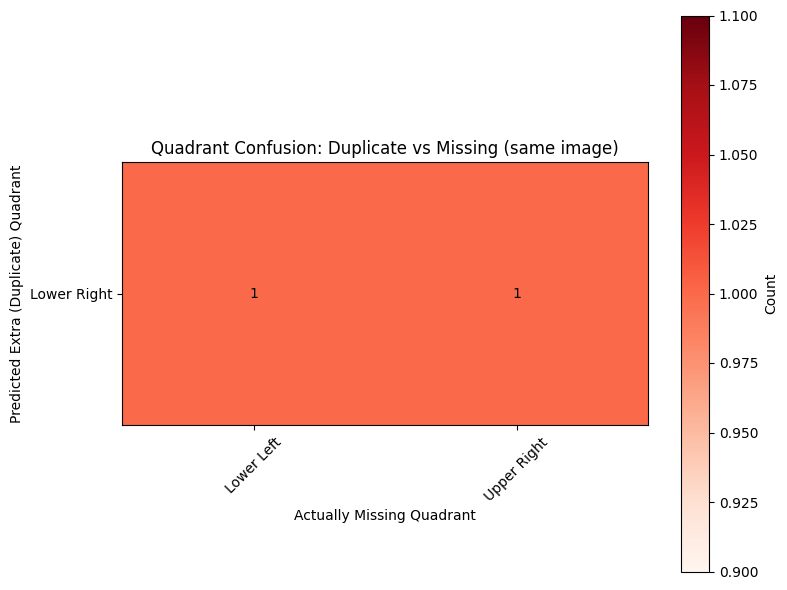


Top 10 problematic images (most warnings):
File_Name
train_273.png    4
train_502.png    2
train_214.png    2
train_174.png    2
train_176.png    1
train_266.png    1
train_255.png    1
train_44.png     1
train_170.png    1
train_615.png    1
Name: count, dtype: int64

Exported worst images log to: ../Runs/Stage 2/Quadrant Model Crop Analysis\test


In [ ]:
s2_test_log_df = s2_test_results['test_set_results']['quadrant_detection_model_last']['log_df']
s2_test_log_summary = analyze_quadrant_predictions(s2_test_log_df, low_conf_threshold=0.6, export_dir='../Runs/Stage 2/Quadrant Model Crop Analysis', split_name='test')

Total images processed: 538
Total events logged: 2720



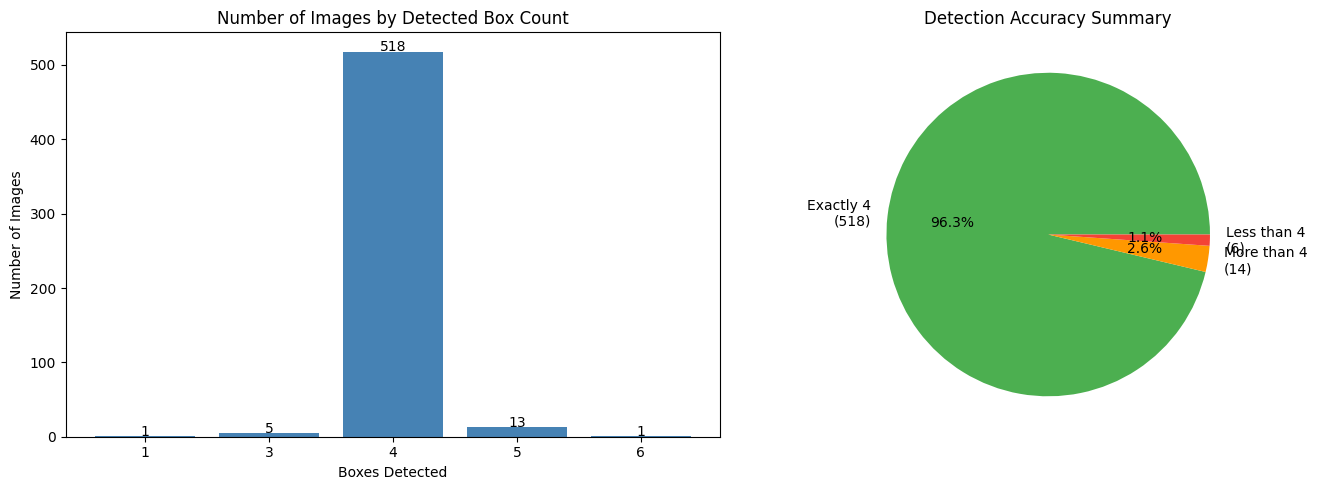

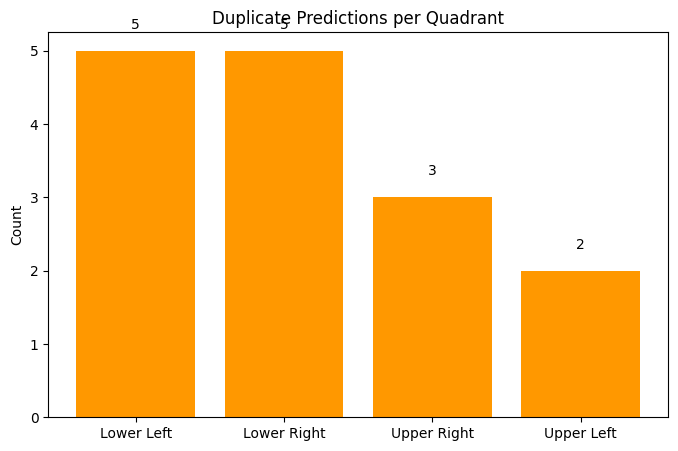

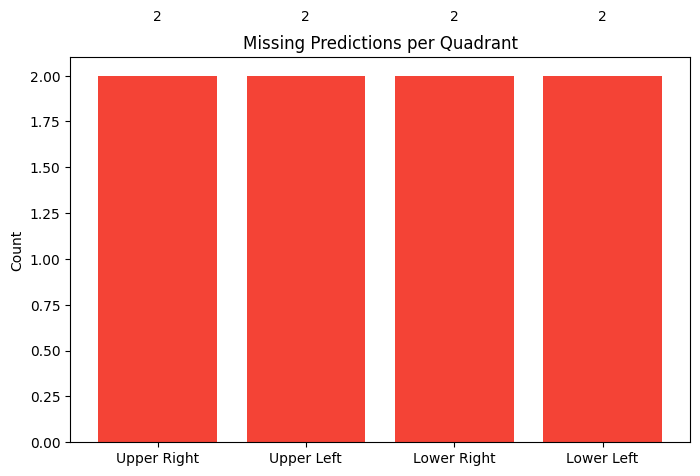

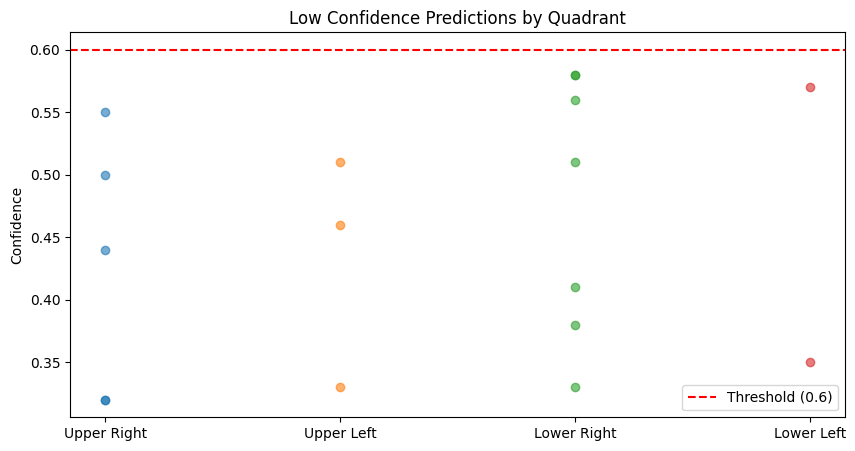


Total low confidence warnings: 17
             count      mean   min
quad                              
Lower Left       2  0.460000  0.35
Lower Right      7  0.478571  0.33
Upper Left       3  0.433333  0.33
Upper Right      5  0.426000  0.32

Average HIGH confidence (>= 0.6): 0.983
Average LOW confidence  (< 0.6): 0.444
Confidence Gap: 0.539  (std=0.083, n_low=43 -> large, model is inconsistent)

No clear duplicate-missing confusion pattern found in the same images.

Top 10 problematic images (most warnings):
File_Name
train_413.png    2
train_363.png    2
train_622.png    2
train_432.png    2
train_589.png    2
train_34.png     2
train_283.png    1
train_654.png    1
train_568.png    1
train_452.png    1
Name: count, dtype: int64

Exported worst images log to: ../Runs/Stage 3/Quadrant Model Crop Analysis\train


In [ ]:
s3_train_log_df = s3_train_results['test_set_results']['quadrant_detection_model_last']['log_df']
s3_train_log_summary = analyze_quadrant_predictions(s3_train_log_df, low_conf_threshold=0.6, export_dir='../Runs/Stage 3/Quadrant Model Crop Analysis', split_name='train')

Total images processed: 67
Total events logged: 339



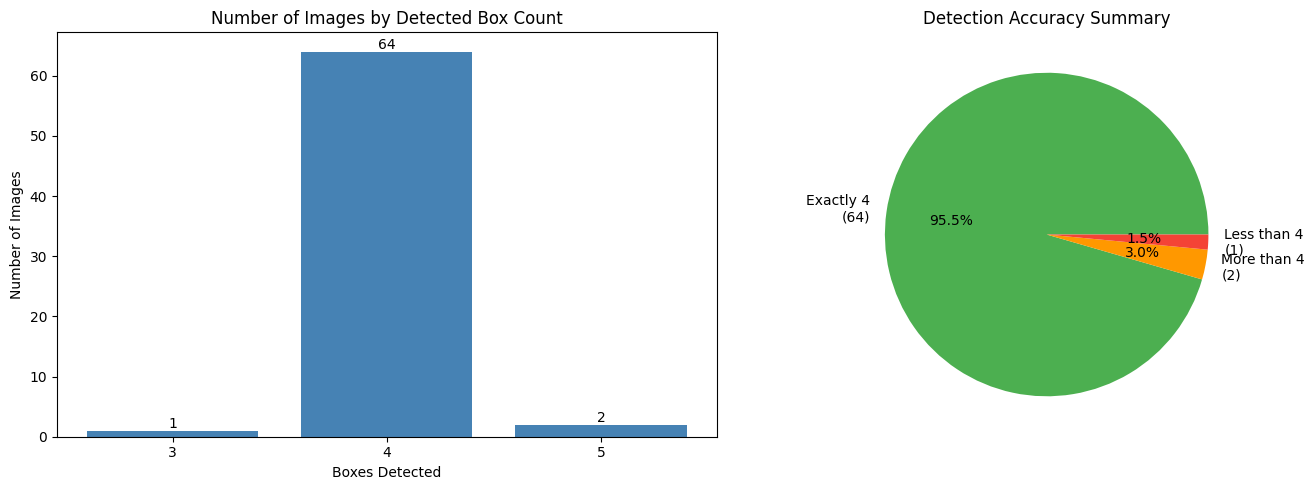

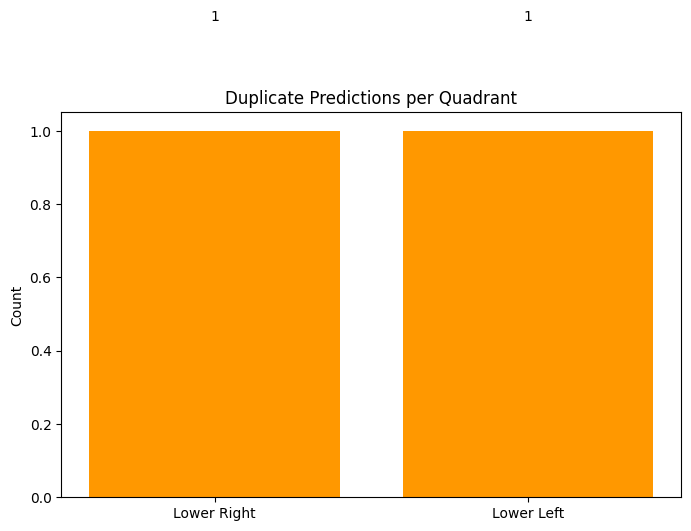

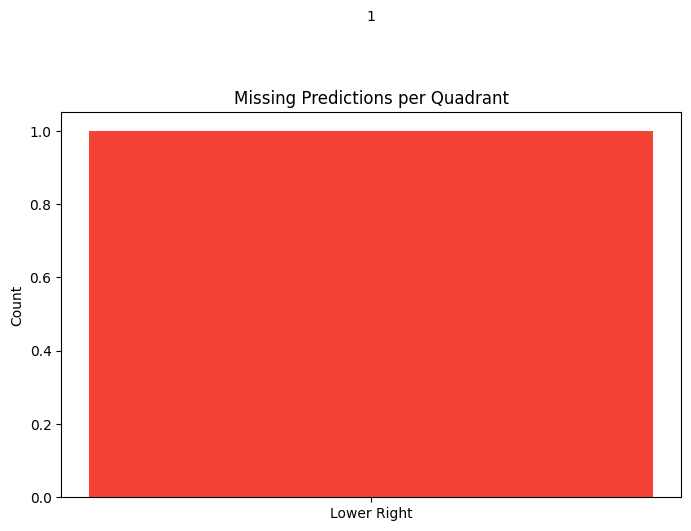

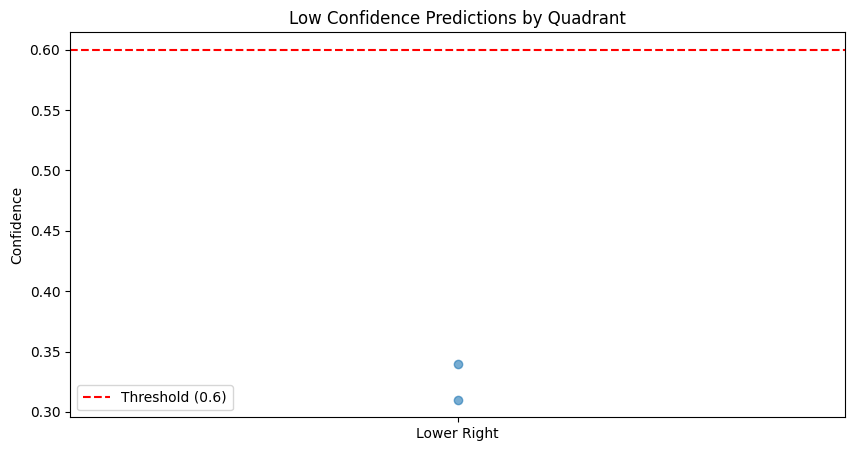


Total low confidence warnings: 2
             count   mean   min
quad                           
Lower Right      2  0.325  0.31

Average HIGH confidence (>= 0.6): 0.981
Average LOW confidence  (< 0.6): 0.370
Confidence Gap: 0.611  (std=0.097, n_low=6 -> large, model is inconsistent)

No clear duplicate-missing confusion pattern found in the same images.

Top 10 problematic images (most warnings):
File_Name
train_480.png    1
train_393.png    1
train_228.png    1
train_367.png    1
train_489.png    1
Name: count, dtype: int64

Exported worst images log to: ../Runs/Stage 3/Quadrant Model Crop Analysis\valid


In [ ]:
s3_valid_log_df = s3_valid_results['test_set_results']['quadrant_detection_model_last']['log_df']
s3_valid_log_summary = analyze_quadrant_predictions(s3_valid_log_df, low_conf_threshold=0.6, export_dir='../Runs/Stage 3/Quadrant Model Crop Analysis', split_name='valid')

Total images processed: 69
Total events logged: 346



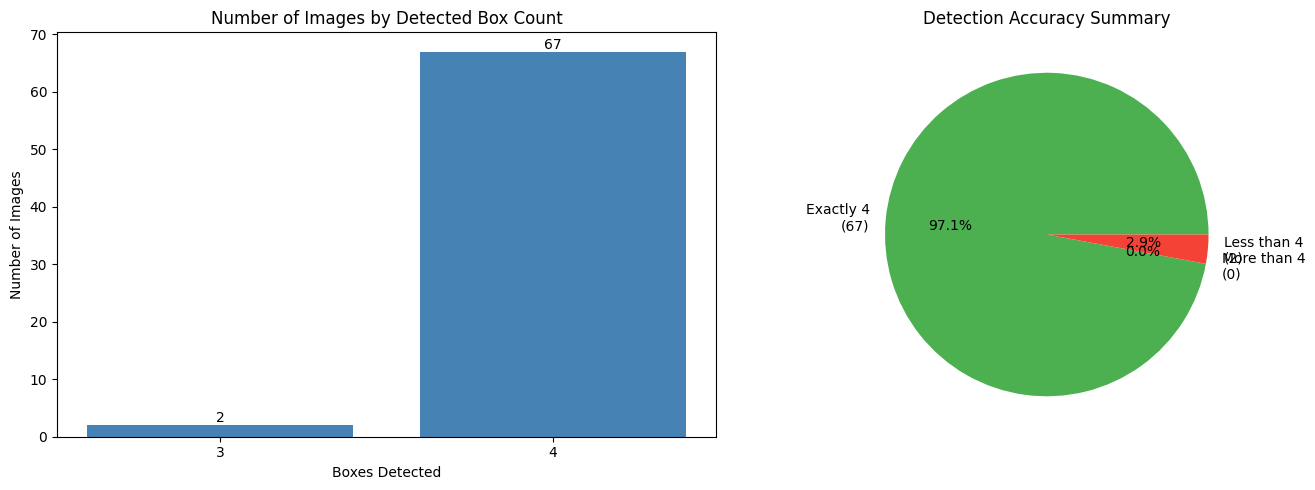

No duplicate quadrant predictions found.


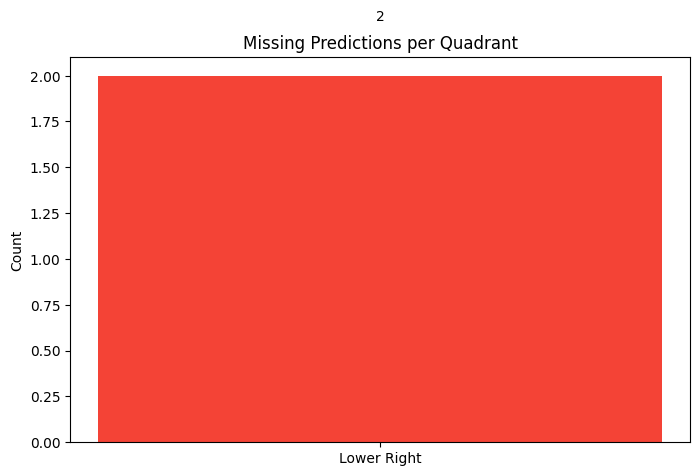

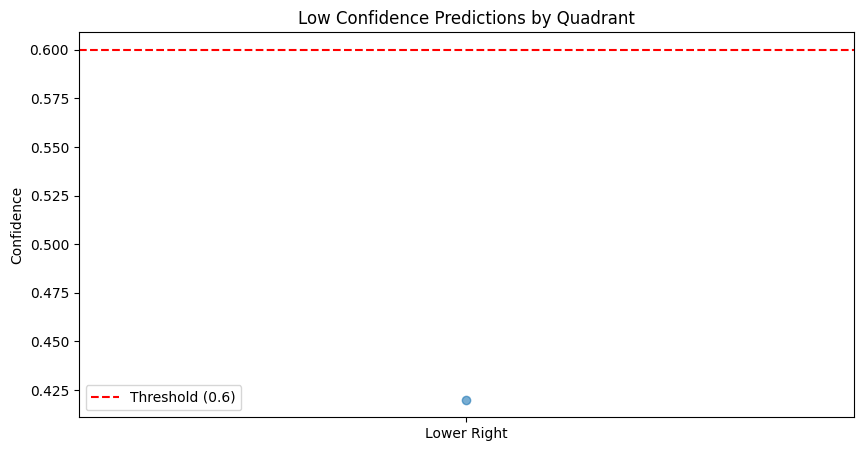


Total low confidence warnings: 1
             count  mean   min
quad                          
Lower Right      1  0.42  0.42

Average HIGH confidence (>= 0.6): 0.982
Average LOW confidence  (< 0.6): 0.420
Confidence Gap: 0.562  (low sample size n=2, result not reliable)

Top 10 problematic images (most warnings):
File_Name
train_188.png    1
train_557.png    1
train_619.png    1
Name: count, dtype: int64

Exported worst images log to: ../Runs/Stage 3/Quadrant Model Crop Analysis\test


In [ ]:
s3_test_log_df = s3_test_results['test_set_results']['quadrant_detection_model_last']['log_df']
s3_test_log_summary = analyze_quadrant_predictions(s3_test_log_df, low_conf_threshold=0.6, export_dir='../Runs/Stage 3/Quadrant Model Crop Analysis', split_name='test')

In [ ]:
s2_train_log_df['event'].unique()

<ArrowStringArray>
['successful_detection',       'boxes_detected',       'duplicate_quad',
       'low_confidence',         'missing_quad']
Length: 5, dtype: str

## Prepare Stage 2 and Stage 3 data

With the quadrant model checked out, let's move on to preparing the enumeration data for Stage 2 and Stage 3. We'll remove bad files then load the pre-split train, valid, and test dataframes and take a quick look at each.

In [ ]:
allowed_events = ['boxes_detected', 'successful_detection']

# these pickles already have the train/valid/test split baked in
bad_train_files = s2_train_log_df[~s2_train_log_df['event'].isin(allowed_events)]['File_Name'].unique()
bad_valid_files = s2_valid_log_df[~s2_valid_log_df['event'].isin(allowed_events)]['File_Name'].unique()
bad_test_files = s2_test_log_df[~s2_test_log_df['event'].isin(allowed_events)]['File_Name'].unique()

# --- 1. Train ---
train_enum_df = pd.read_pickle(os.path.join(stage2_config['paths']['s2_main_path'], 'train_df (splitted).pkl'))
train_enum_df.drop(train_enum_df[train_enum_df['File_Name'].isin(bad_train_files)].index, inplace=True)

# --- 2. Valid ---
valid_enum_df = pd.read_pickle(os.path.join(stage2_config['paths']['s2_main_path'], 'valid_df (splitted).pkl'))
valid_enum_df.drop(valid_enum_df[valid_enum_df['File_Name'].isin(bad_valid_files)].index, inplace=True)

# --- 3. Test ---
test_enum_df = pd.read_pickle(os.path.join(stage2_config['paths']['s2_main_path'], 'test_df (splitted).pkl'))
test_enum_df.drop(test_enum_df[test_enum_df['File_Name'].isin(bad_test_files)].index, inplace=True)

# --- Print Results ---
print('Train Rows:', train_enum_df.shape[0])
print('Valid Rows:', valid_enum_df.shape[0])
print('Test Rows:',  test_enum_df.shape[0])

Train Rows: 13619
Valid Rows: 1649
Test Rows: 1770


In [ ]:
bad_train_files = s3_train_log_df[~s3_train_log_df['event'].isin(allowed_events)]['File_Name'].unique()
bad_valid_files = s3_valid_log_df[~s3_valid_log_df['event'].isin(allowed_events)]['File_Name'].unique()
bad_test_files = s3_test_log_df[~s3_test_log_df['event'].isin(allowed_events)]['File_Name'].unique()

# --- 1. Train ---
train_dis_df = pd.read_pickle(os.path.join(stage3_config['paths']['s3_main_path'], 'train_df (splitted).pkl'))
train_dis_df.drop(train_dis_df[train_dis_df['File_Name'].isin(bad_train_files)].index, inplace=True)

# --- 2. Valid ---
valid_dis_df = pd.read_pickle(os.path.join(stage3_config['paths']['s3_main_path'], 'valid_df (splitted).pkl'))
valid_dis_df.drop(valid_dis_df[valid_dis_df['File_Name'].isin(bad_valid_files)].index, inplace=True)

# --- 3. Test ---
test_dis_df = pd.read_pickle(os.path.join(stage3_config['paths']['s3_main_path'], 'test_df (splitted).pkl'))
test_dis_df.drop(test_dis_df[test_dis_df['File_Name'].isin(bad_test_files)].index, inplace=True)

# --- Print Results ---
print('Train Rows:', train_dis_df.shape[0])
print('Valid Rows:', valid_dis_df.shape[0])
print('Test Rows:',  test_dis_df.shape[0])

Train Rows: 2675
Valid Rows: 324
Test Rows: 305


## Export quadrant crops

Now we'll use the quadrant model to crop every image into its four quadrants, matched up with the enumeration labels for Stage 2. First, a small debug run on 8 images to make sure everything lines up before running a full split.

In [ ]:
# load the checkpoint saved at the end of training, this is the model we'll actually use for inference
quadrant_model_detection = YOLO(trained_models_config['quadrant_detection_model']['last'])

  0%|          | 1/476 [00:00<02:28,  3.21it/s]

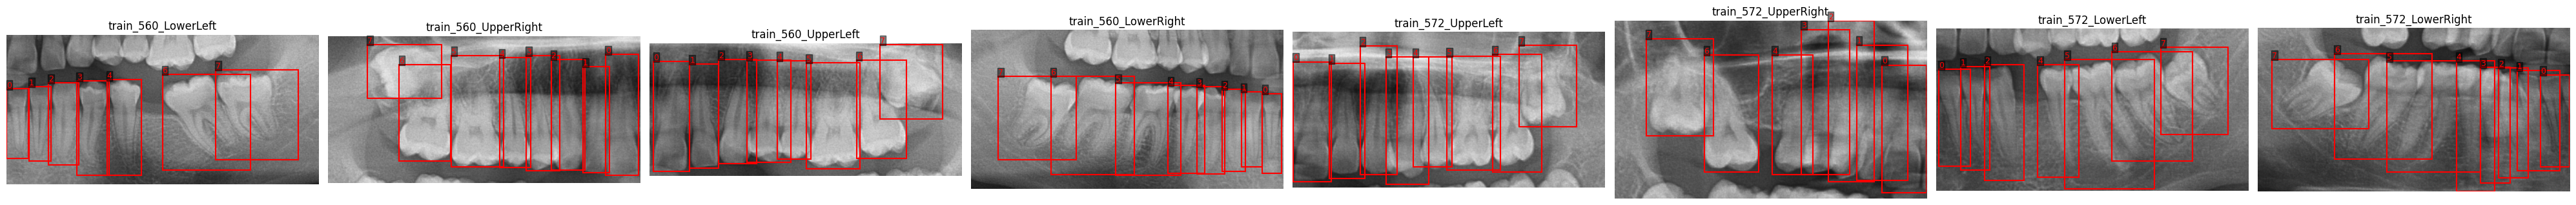

  0%|          | 1/476 [00:01<08:38,  1.09s/it]


In [ ]:
# debug_limit caps this to 8 images so we can eyeball the crops before running the full split
export_enum_by_quad_using_model(quadrant_model_detection,
                                stage2_config['paths']['original_images_path'],
                                train_enum_df,
                                os.path.join(stage2_config['paths']['s2_main_path'],'train'), 
                                debugging=True,debug_limit=8,)

  0%|          | 1/506 [00:00<02:52,  2.93it/s]

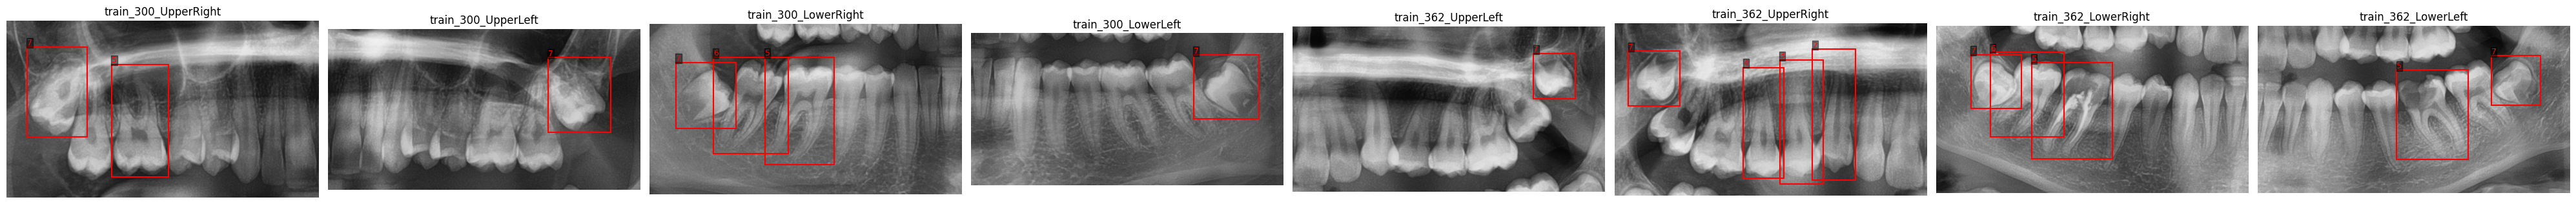

  0%|          | 1/506 [00:01<09:04,  1.08s/it]


In [ ]:
# debug_limit caps this to 8 images so we can eyeball the crops before running the full split
export_enum_by_quad_using_model(quadrant_model_detection,
                                stage3_config['paths']['original_images_path'],
                                train_dis_df,
                                os.path.join(stage2_cont_config['paths']['s2_cont_main_path'], 'train'), 
                                debugging=True,debug_limit=8)

## Train split

That looks right, so let's run it on the full train split.

In [ ]:
# conf_threshold filters out low-confidence quadrant detections before exporting crops
_ = export_enum_by_quad_using_model(quadrant_model_detection,
                                        stage2_config['paths']['original_images_path'],
                                        train_enum_df,os.path.join(stage2_config['paths']['s2_main_path'], 'train'),
                                        conf_threshold=0.3, verbose=False)

Deleted 16926 files. Failed: 0.


100%|██████████| 476/476 [01:45<00:00,  4.51it/s]


In [ ]:
# conf_threshold filters out low-confidence quadrant detections before exporting crops
_ = export_enum_by_quad_using_model(quadrant_model_detection,
                                        stage2_cont_config['paths']['original_images_path'],
                                        train_dis_df,os.path.join(stage2_cont_config['paths']['s2_cont_main_path'], 'train'),
                                        conf_threshold=0.3, verbose=False)

100%|██████████| 506/506 [01:50<00:00,  4.59it/s]


## Valid split

Same steps now for the validation split.

In [ ]:
_ = export_enum_by_quad_using_model(quadrant_model_detection,
                                        stage2_config['paths']['original_images_path'],
                                        valid_enum_df,
                                        os.path.join(stage2_config['paths']['s2_main_path'], 'valid'),
                                        conf_threshold=0.3, verbose=False)

Deleted 472 files. Failed: 0.


100%|██████████| 59/59 [00:12<00:00,  4.80it/s]


In [ ]:
_ = export_enum_by_quad_using_model(quadrant_model_detection,
                                        stage2_cont_config['paths']['original_images_path'],
                                        valid_dis_df,
                                        os.path.join(stage2_cont_config['paths']['s2_cont_main_path'], 'valid'),
                                        conf_threshold=0.3, verbose=False)

100%|██████████| 62/62 [00:13<00:00,  4.61it/s]


## Test split

And finally the test split.

In [ ]:
# same export step, now for the test split
_ = export_enum_by_quad_using_model(quadrant_model_detection,
                                        stage2_config['paths']['original_images_path'],
                                        test_enum_df, 
                                        os.path.join(stage2_config['paths']['s2_main_path'], 'test'),
                                        conf_threshold=0.3, verbose=False)

Deleted 512 files. Failed: 0.


100%|██████████| 62/62 [00:12<00:00,  4.96it/s]


In [ ]:
_ = export_enum_by_quad_using_model(quadrant_model_detection,
                                        stage2_cont_config['paths']['original_images_path'],
                                        test_dis_df,
                                        os.path.join(stage2_cont_config['paths']['s2_cont_main_path'], 'test'),
                                        conf_threshold=0.3, verbose=False)

100%|██████████| 66/66 [00:14<00:00,  4.68it/s]


## Augment the enumeration data

With the quadrant crops ready, let's set up augmentation for the enumeration data. `apply_smart_aug` does the actual transforms; here we just define the config: small rotations, mild brightness and contrast jitter, CLAHE for contrast enhancement, and a resized crop, each with its own probability so not every image gets every transform.

In [ ]:
ENUM_AUG_CONFIG = {
    'rotate_limit': 6,
    'rotate_p': 0.3,
    'brightness_limit': 0.1,
    'contrast_limit': 0.1,
    'brightness_contrast_p': 0.4,
    'center_crop_ratio': 1.0, # No need to center crop
    'clahe_clip_limit': 2.0,
    'clahe_p': 0.5,
    'resized_crop_scale': (0.9, 1.0),
    'ratio_margin_low': 0.95,
    'ratio_margin_high': 1.05,
    'resized_crop_p': 0.5,
    'min_visibility': 0.6,
}

Let's run it in debug mode first and look at a few augmented samples before applying it for real.

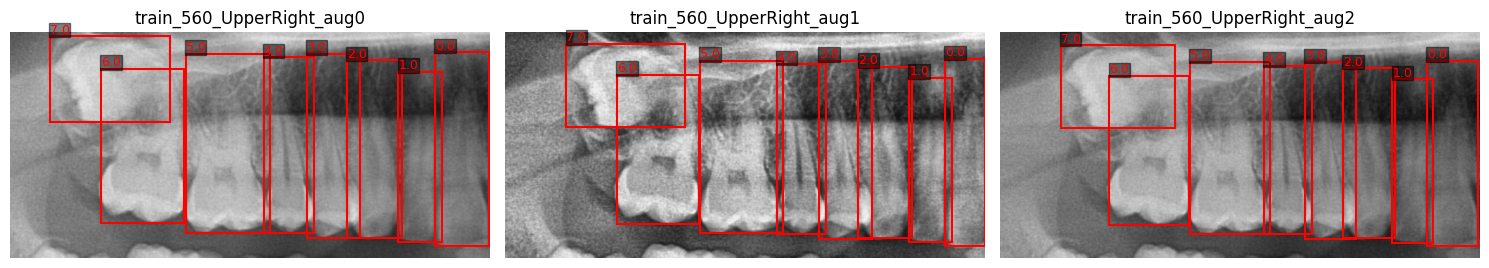

In [ ]:
apply_smart_aug(enum_data_yaml,ENUM_AUG_CONFIG,apply_debug=True)

In [ ]:
# WE WILL NOT APPLY AUG ON DISEASE FOR NOW UNTIL THE ENUM MODEL IS READY TO PREDICT ALL OTHER TEETH IN DISEASE DATA

That looks good, so let's apply it on the full dataset.

In [ ]:
apply_smart_aug(enum_data_yaml,ENUM_AUG_CONFIG)

Augmenting Images Now...: 100%|██████████| 1901/1901 [02:40<00:00, 11.85it/s]
